# 04 — Prices formed by queues emptying

The queue-reactive model of Huang, Lehalle and Rosenbaum contains no price
process.  The book is a Markov jump process whose event rates depend on the
queue sizes, and the price is a consequence: when a queue at the best empties,
the best price on that side moves a tick.  Volatility is an *output*.

Estimation needs no optimiser.  For a Markov jump process the maximum
likelihood estimate of an intensity is the count over the time spent in the
state, $\hat\lambda_e(q) = N_e(q)/T(q)$, and both counters are accumulated in
the same pass that rebuilds the book.

In [1]:
import sys, os
sys.path.insert(0, os.path.join("..", "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from hfx.viz import subplots, use_style, colour_for, tick_regime
from hfx.pipeline.results import panel, curves, curve, symbol_days
use_style()
P = panel(); C = curves()
DAY = "2019-01-30"
print(f"{len(P)} symbol-days, {P.symbol.nunique()} symbols, {P.date.nunique()} dates")

84 symbol-days, 12 symbols, 7 dates


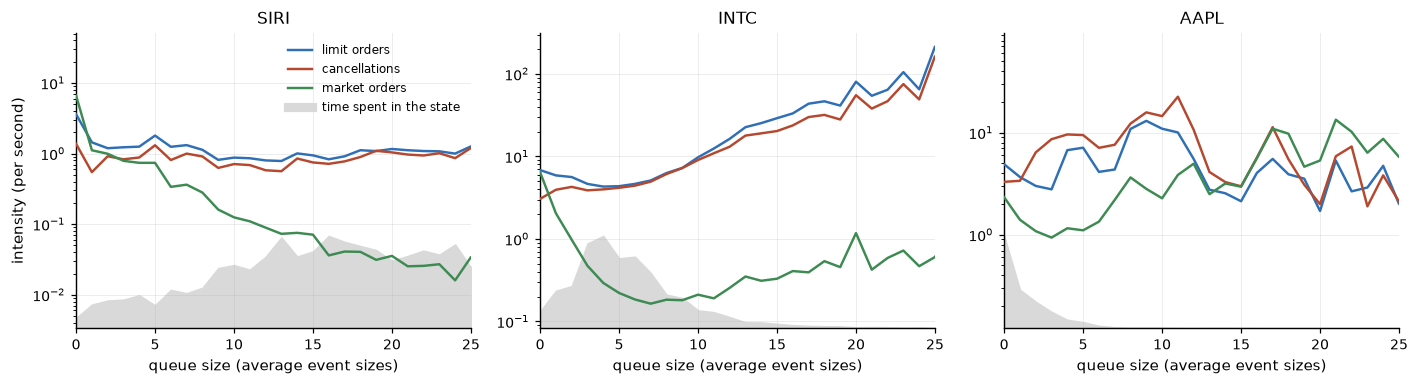

In [2]:
from hfx.queue import reactive as qr
from hfx.book.replay import NQ, size_bucket_centres

fig, axes = subplots(1, 3, figsize=(13, 3.6))
for ax, sym in zip(axes, ["SIRI", "INTC", "AAPL"]):
    lam = curve(C, sym, DAY, "qr_lambda")
    seconds = curve(C, sym, DAY, "qr_time") / 1e9
    q = np.arange(lam.shape[1])
    # The time spent in each state is the denominator of every rate above it.
    ax2 = ax.twinx()
    ax2.fill_between(q, seconds, color="0.85", zorder=0)
    ax2.set_ylim(0, seconds.max() * 3.2); ax2.set_yticks([]); ax2.grid(False)
    for i, label in enumerate(["limit orders", "cancellations", "market orders"]):
        ax.plot(q, lam[i], label=label, zorder=3)
    ax.set_zorder(ax2.get_zorder() + 1); ax.patch.set_visible(False)
    ax.set_yscale("log"); ax.set_xlim(0, 25); ax.set_title(sym)
    ax.set_xlabel("queue size (average event sizes)")
axes[0].set_ylabel("intensity (per second)")
axes[0].plot([], [], color="0.85", lw=6, label="time spent in the state")
axes[0].legend(fontsize=8)
plt.tight_layout()

**Market orders fall sharply with the queue.** Between an empty best
queue and one holding five average orders the market-order intensity drops by a
factor of 9 on SIRI, 29 on INTC and 9 on MSFT: takers arrive when the queue in
front of them is thin, which is the effect the model is named for and the reason
a queue that starts to empty tends to keep emptying.

**Limit orders and cancellations move together, and much less.** They track each
other to within a tenth over most of the range -- which is exactly what keeps a
queue alive -- with cancellations roughly doubling between an empty queue and one
holding eight average orders on INTC and MSFT.

**Beyond about ten average sizes, read the curves with the residence time next to
them.** Both intensities climb steeply there, and the reason is visible in the
denominator: INTC spends 69 seconds of its day with 20 average orders resting at
the best and 11 seconds with 30. Those states are entered and left by a single
large order, so a count over a very short residence time is a large rate. The
estimator is not wrong; the state is rare, and the third panel shows what that
looks like on a name whose best queue holds under two average orders to begin
with.

## What the estimated dynamics produce

A queue does not move by one average event at a time: order sizes on Nasdaq
span a decade, and a queue that dies in one large cancellation dies much sooner
than a diffusive count of average events suggests.  The simulator therefore
draws real sizes from the measured distribution, which is the difference between
reproducing the rate of price changes and missing it by three orders of
magnitude.

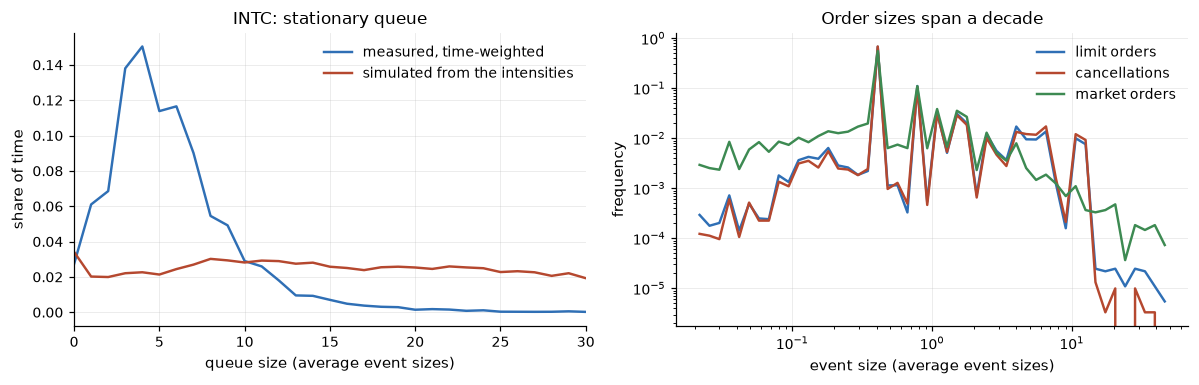

In [3]:
fig, axes = subplots(1, 2, figsize=(11, 3.6))
sym = "INTC"
emp = curve(C, sym, DAY, "qr_queue_emp"); sim = curve(C, sym, DAY, "qr_queue_sim")
axes[0].plot(np.arange(len(emp)), emp, label="measured, time-weighted")
axes[0].plot(np.arange(len(sim)), sim, label="simulated from the intensities")
axes[0].set_xlim(0, 30); axes[0].set_xlabel("queue size (average event sizes)")
axes[0].set_ylabel("share of time"); axes[0].set_title(f"{sym}: stationary queue"); axes[0].legend()
centres = size_bucket_centres()
for i, label in enumerate(["limit orders", "cancellations", "market orders"]):
    h = curve(C, sym, DAY, "size_hist")[i].astype(float)
    axes[1].loglog(centres, h / h.sum(), label=label)
axes[1].set_xlabel("event size (average event sizes)"); axes[1].set_ylabel("frequency")
axes[1].set_title("Order sizes span a decade"); axes[1].legend()
plt.tight_layout()

In [4]:
q = P.groupby("symbol").agg(price=("price", "mean"), spread=("median_spread_ticks", "mean"),
                            realized=("vol_preavg_pct", "mean"),
                            model_full=("qr_vol_pct", "mean"),
                            model_half=("qr_vol_half_pct", "mean"),
                            holding=("qr_holding_s", "mean")).sort_values("spread")
q["full / realized"] = q.model_full / q.realized
q["half / realized"] = q.model_half / q.realized
print(q.round(3).to_string())
large = q[q.spread <= 1.2]
print(f"\none-tick-spread names, half-tick convention: "
      f"{100 * (large['half / realized'] - 1).abs().max():.0f}% worst error")

           price  spread  realized  model_full  model_half  holding  full / realized  half / realized
symbol                                                                                               
CSCO      49.214   1.000     0.945       1.518       0.759    4.616            1.606            0.803
INTC      54.482   1.000     1.073       1.900       0.950    3.141            1.771            0.886
MU        46.425   1.000     1.750       2.621       1.311    1.665            1.497            0.749
SIRI       6.380   1.000     1.214       3.276       1.638   71.120            2.699            1.350
MSFT     139.119   1.143     0.971       1.015       0.507    1.307            1.046            0.523
AAPL     231.725   2.286     1.176       0.933       0.467    0.650            0.794            0.397
NFLX     324.252  12.143     1.561       0.362       0.181    1.903            0.232            0.116
TSLA     344.886  15.571     2.036       0.399       0.199    1.570            0.1

The model shifts the whole book by a tick when a queue empties, which
is what a book with a one-tick spread has to do.  A real book usually moves one
side at a time, and the mid with it by half a tick.  Both conventions are
reported because which one applies is an empirical question about the spread,
not a choice: on the names whose spread is pinned at one tick the half-tick
reading is right and lands within about ten percent of the realized volatility,
while on the fifty-tick names the mechanism does not apply at all and the model
under-predicts by an order of magnitude.

That is the price-formation statement of this repository.  Nothing in the
estimation saw a price.  The intensities were measured against queue sizes; the
volatility came out.

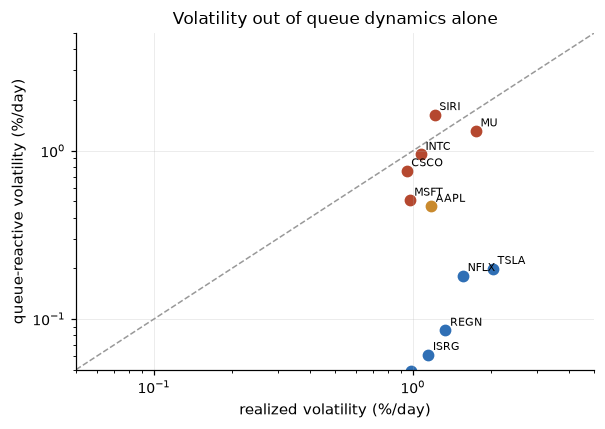

In [5]:
fig, ax = subplots(figsize=(5.6, 4.0))
for sym, r in q.iterrows():
    ax.scatter(r.realized, r.model_half, color=colour_for(r.spread), s=45)
    ax.annotate(sym, (r.realized, r.model_half), fontsize=7, xytext=(3, 3), textcoords="offset points")
lim = [0.05, 5]
ax.plot(lim, lim, color="0.6", lw=1, ls="--")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("realized volatility (%/day)"); ax.set_ylabel("queue-reactive volatility (%/day)")
ax.set_title("Volatility out of queue dynamics alone")
plt.tight_layout()

## The by-product: how often a limit order at the touch gets filled

Because the feed is order by order, we know where every order sat in its queue
when it arrived and what became of it.  This is the input chapter 05 needs, and
it cannot be measured from aggregated data at all.

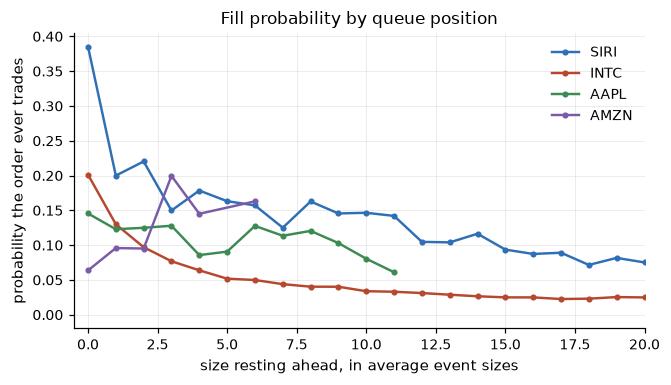

In [6]:
fig, ax = subplots(figsize=(6.2, 3.6))
for sym in ["SIRI", "INTC", "AAPL", "AMZN"]:
    f = curve(C, sym, DAY, "fill_counts")[0].astype(float)   # orders that joined the touch
    total = f.sum(axis=1)
    ok = total > 200
    filled = (f[:, 0] + f[:, 1]) / np.maximum(total, 1)
    ax.plot(np.arange(len(total))[ok], filled[ok], "o-", ms=3, label=sym)
ax.set_xlim(-0.5, 20); ax.set_xlabel("size resting ahead, in average event sizes")
ax.set_ylabel("probability the order ever trades")
ax.set_title("Fill probability by queue position"); ax.legend()
plt.tight_layout()